In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [3]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [4]:
df[["sex", "smoker", "region"]] = df[["sex", "smoker", "region"]].apply(lambda x: x.str.lower())

In [5]:
df["sex"] = df["sex"].map({"female" : 1, "male" : 0})
df["smoker"] = df["smoker"].map({"yes" : 1, "no" : 0})
df["region"] = df["region"].map({"northeast" : 1, "northwest" : 2, "southeast" : 3, "southwest": 4})

In [6]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

X = df.drop("expenses", axis=1)
y = df["expenses"]

n = len(X)
train_size = int(0.8 * n)

x_train = X[:train_size].copy()
x_test = X[train_size:].copy()

y_train = y[:train_size].copy()
y_test = y[train_size:].copy()
x_features = ["age", "sex", "bmi", "children", "smoker", "region"]

In [7]:
x_train = x_train.to_numpy()
x_test = x_test.to_numpy()

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

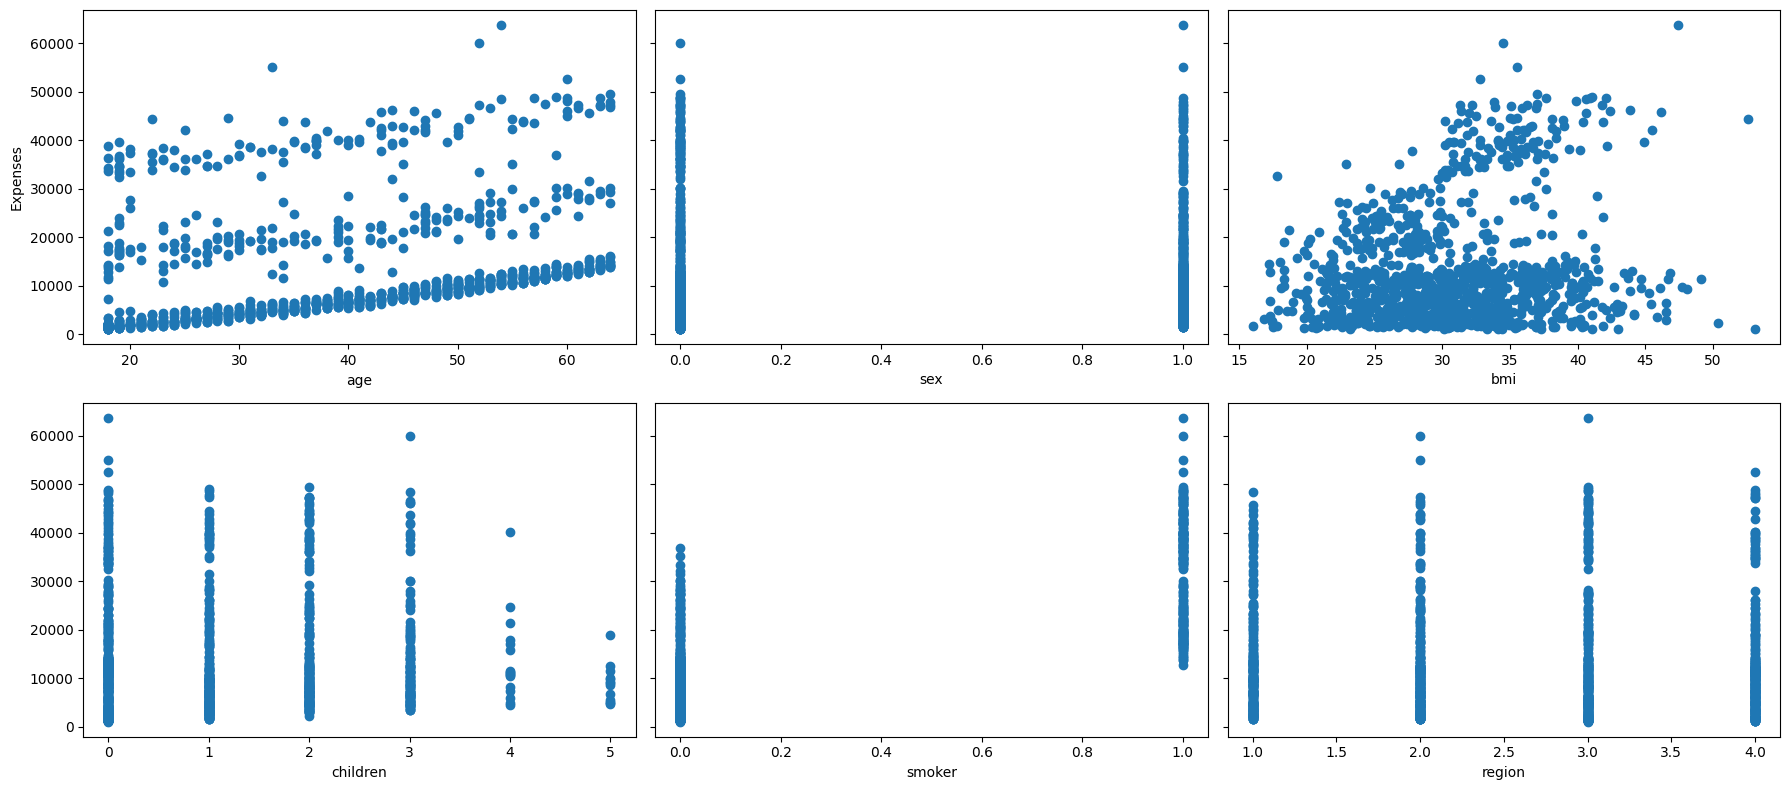

In [8]:
fig,ax=plt.subplots(2, 3, figsize=(18, 8), sharey=True)
ax = ax.ravel()
for i in range(len(ax)):
    ax[i].scatter(x_train[:,i],y_train)
    ax[i].set_xlabel(x_features[i])
ax[0].set_ylabel("Expenses")
plt.tight_layout()
plt.show()

In [9]:
means = np.mean(x_train, axis=0)
stds = np.std(x_train, axis=0)

x_train = (x_train - means) / stds
x_test = (x_test - means) / stds

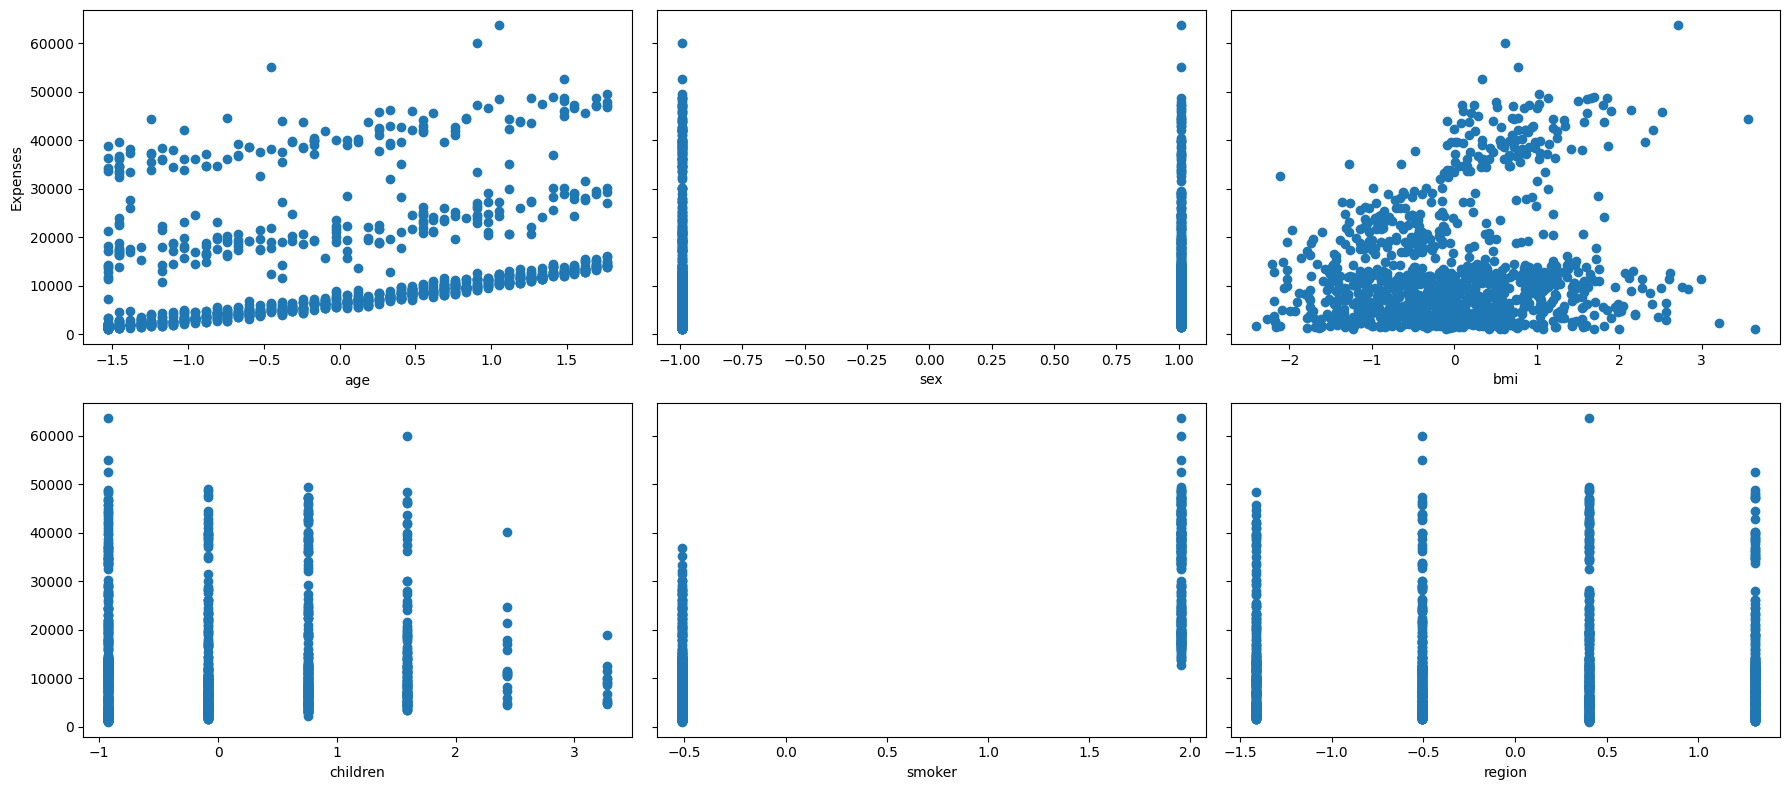

In [10]:
fig, ax = plt.subplots(2, 3, figsize=(18, 8), sharey=True)

ax = ax.ravel()

for i in range(len(ax)):
    ax[i].scatter(x_train[:, i], y_train)
    ax[i].set_xlabel(x_features[i])

ax[0].set_ylabel("Expenses")

plt.tight_layout()
plt.show()

In [11]:
b_init = 0
w_init = np.zeros(x_train.shape[1])

In [12]:
def predict(x,w,b):
    p = np.dot(x,w) + b
    return p

In [13]:
x_vec = x_train[0:1]
predict(x_vec,w_init,b_init)

array([0.])

In [14]:
def compute_cost(x, y, w, b):
    m = x.shape[0]

    predictions = np.dot(x, w) + b
    cost = np.sum((predictions - y) ** 2) / (2 * m)

    return cost

In [15]:
cost = compute_cost(x_train, y_train, w_init, b_init)
cost

np.float64(160709678.50586352)

In [16]:
def compute_grades(x, y, w, b):
    m = x.shape[0]

    predictions = np.dot(x, w) + b
    errors = predictions - y

    dj_dw = np.dot(x.T, errors) / m
    dj_db = np.sum(errors) / m

    return dj_db, dj_dw

In [17]:
tmp_dj_db, tmp_dj_dw = compute_grades(x_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: -13314.712813084114
dj_dw at initial w,b: 
 [-3565.51532454   828.31759733 -2344.62585547  -721.19251135
 -9431.12833011   -22.45792506]


In [18]:
import copy
import math

def grades(x, y, w_in, b_in, cost_func, grad_func, alpha, iters):
    J_hist = []

    w = w_in
    b = b_in

    for i in range(iters):

        predictions = np.dot(x, w) + b
        errors = predictions - y

        dj_dw = np.dot(x.T, errors) / len(y)
        dj_db = np.sum(errors) / len(y)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = np.sum((np.dot(x, w) + b - y) ** 2) / (2 * len(y))
        J_hist.append(cost)

        if i % math.ceil(iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {cost:8.2f}")

    return w, b, J_hist

In [45]:
iterations = 1000
alpha = 0.01
w_final, b_final, J_hist = grades(x_train, y_train, w_init, b_init, compute_cost, compute_grades, alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = x_train.shape
for i in range(10):
    print(f"prediction: {np.dot(x_test[i], w_final) + b_final:0.2f}, target value: {y_test[i]}")

Iteration    0: Cost 157867584.86
Iteration  100: Cost 36865837.44
Iteration  200: Cost 20587389.15
Iteration  300: Cost 18365259.30
Iteration  400: Cost 18058059.62
Iteration  500: Cost 18015109.03
Iteration  600: Cost 18009041.49
Iteration  700: Cost 18008175.91
Iteration  800: Cost 18008051.26
Iteration  900: Cost 18008033.14
b,w found by gradient descent: 13314.14,[3652.19932294   22.73503654 1941.52832737  588.00982922 9558.15986753
 -385.73000833] 
prediction: 10442.26, target value: 8413.46
prediction: 12440.79, target value: 10928.85
prediction: 27250.01, target value: 35147.53
prediction: 24636.32, target value: 15518.18
prediction: 12269.42, target value: 10797.34
prediction: 3430.29, target value: 1909.53
prediction: 6908.65, target value: 3268.85
prediction: 12837.32, target value: 26392.26
prediction: 27662.46, target value: 16776.3
prediction: 4906.88, target value: 26018.95


In [46]:
predictions = []

for i in range(len(x_test)):
    pred = np.dot(x_test[i], w_final) + b_final
    predictions.append(pred)

predictions = pd.Series(predictions)

In [49]:
predictions = pd.Series(predictions)

mae = (abs(y_test - predictions)).mean()

mse = ((y_test - predictions) ** 2).mean()

rmse = np.sqrt(mse)

ss_total = ((y_test - y_test.mean()) ** 2).sum()
ss_residual = ((y_test - predictions) ** 2).sum()
r2 = 1 - (ss_residual / ss_total)

predictions = predictions.clip(lower=0)

rmsle = np.sqrt(((np.log1p(y_test) - np.log1p(predictions)) ** 2).mean())

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("RMSLE:", rmsle)

MAE: 4046.935792415712
MSE: 38699932.692443706
RMSE: 6220.9269962316475
R2 Score: 0.7520914269584408
RMSLE: 0.9449022810462735


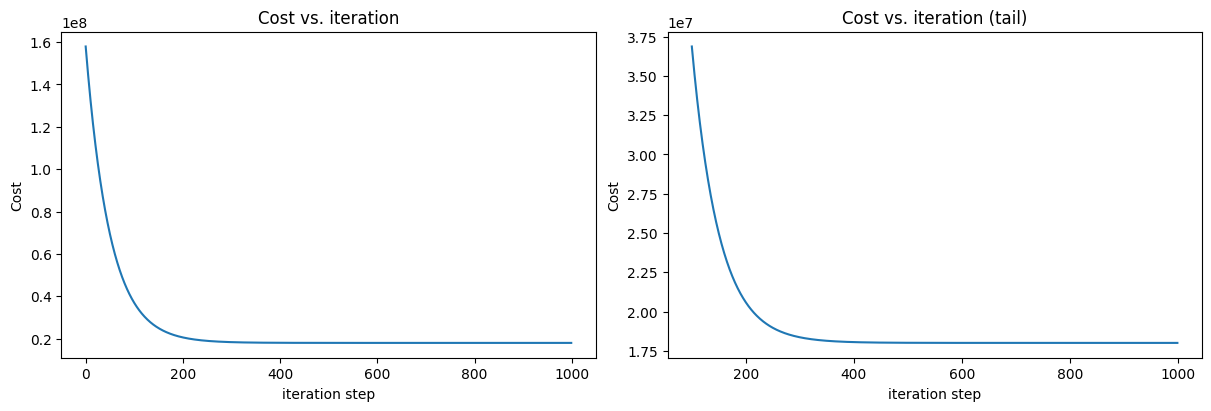

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()